In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

In [17]:
np.random.seed(42)

df = pd.DataFrame({
    'customer_id':   range(1, 301),
    'age':           np.random.randint(18, 70, 300),
    'income':        np.random.exponential(60000, 300),
    'num_purchases': np.random.randint(0, 100, 300),
    'total_spent':   np.random.exponential(3000, 300),
    'city':          np.random.choice(['Lagos', 'Abuja', 'Kano', 'PH'], 300),
    'gender':        np.random.choice(['M', 'F'], 300),
    'signup_date':   pd.date_range('2022-01-01', periods=300, freq='D'),
    'churned':       np.random.choice([0, 1], 300, p=[0.7, 0.3])
})

df

,customer_id,age,income,num_purchases,total_spent,city,gender,signup_date,churned
0,1,56,128548.679203,91,985.425092,Abuja,F,2022-01-01,0
1,2,69,12547.568477,35,4402.421275,Lagos,M,2022-01-02,0
2,3,46,19616.263709,89,621.233946,Kano,F,2022-01-03,0
3,4,32,72309.976969,7,1173.263439,Kano,F,2022-01-04,0
4,5,60,112506.302996,57,1662.433650,Kano,M,2022-01-05,0
...,...,...,...,...,...,...,...,...,...
295,296,18,191217.064288,65,338.156744,PH,M,2022-10-23,0
296,297,65,3576.331958,78,234.331517,Lagos,F,2022-10-24,0
297,298,29,30104.203058,74,3907.942231,Lagos,M,2022-10-25,1
298,299,22,6773.734378,7,2052.510680,Lagos,M,2022-10-26,0


Text(0, 0.5, 'total_spend')

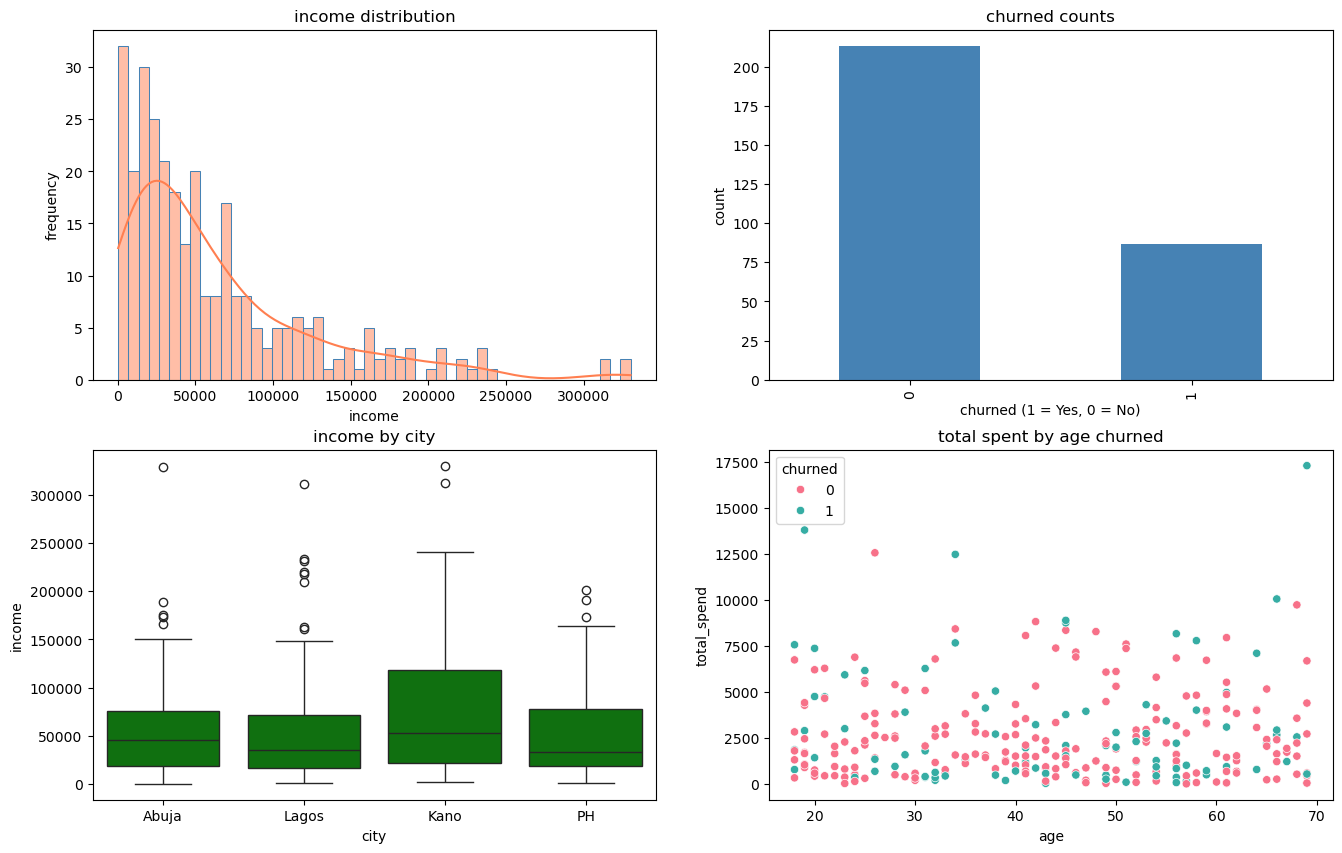

In [18]:
# Exercise 1 — Visualization
# Create a figure with 4 subplots in a 2x2 grid showing:

# - Top left:  Distribution of income (histogram with KDE)
# - Top right: Churned vs Not Churned count (bar chart)
# - Bottom left: Income by city (boxplot)
# - Bottom right: Age vs Total Spent colored by churned (scatterplot)
# Give every chart a title and axis labels


fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# histogram with kernel density estimate(kde)
sns.histplot(data = df['income'], bins = 50, kde = True, color = 'coral', edgecolor = 'steelblue', ax = axes[0, 0])
axes[0, 0].set_title('income distribution')
axes[0, 0].set_xlabel('income')
axes[0, 0].set_ylabel('frequency')


# bar chart for churned

df['churned'].value_counts().plot(kind = 'bar', color = 'steelblue', ax = axes[0, 1])
axes[0, 1].set_title('churned counts')
axes[0, 1].set_xlabel('churned (1 = Yes, 0 = No)')
axes[0, 1].set_ylabel('count')


# boxplot for income per city

sns.boxplot(data = df, x = 'city', y = 'income', ax = axes[1, 0], color = 'green')
axes[1, 0].set_title('income by city')


# scatter plot for money spent by age

sns.scatterplot(data = df, x = 'age', y = 'total_spent', hue = 'churned', palette = 'husl', ax = axes[1 ,1])
axes[1, 1].set_title('total spent by age churned')
axes[1, 1].set_xlabel('age')
axes[1, 1].set_ylabel('total_spend')

In [19]:
df.head()

,customer_id,age,income,num_purchases,total_spent,city,gender,signup_date,churned
0,1,56,128548.679203,91,985.425092,Abuja,F,2022-01-01,0
1,2,69,12547.568477,35,4402.421275,Lagos,M,2022-01-02,0
2,3,46,19616.263709,89,621.233946,Kano,F,2022-01-03,0
3,4,32,72309.976969,7,1173.263439,Kano,F,2022-01-04,0
4,5,60,112506.302996,57,1662.433650,Kano,M,2022-01-05,0


In [20]:
# Exercise 2 — Feature Engineering
# From the existing columns, create ALL of these new features:
# - 'days_since_signup': days between signup_date and 2023-12-31

later_date = pd.to_datetime('2023-12-31')
later_date

df['days_since_signup'] = (later_date - pd.to_datetime(df['signup_date'])).dt.days

df.head()

,customer_id,age,income,num_purchases,total_spent,city,gender,signup_date,churned,days_since_signup
0,1,56,128548.679203,91,985.425092,Abuja,F,2022-01-01,0,729
1,2,69,12547.568477,35,4402.421275,Lagos,M,2022-01-02,0,728
2,3,46,19616.263709,89,621.233946,Kano,F,2022-01-03,0,727
3,4,32,72309.976969,7,1173.263439,Kano,F,2022-01-04,0,726
4,5,60,112506.302996,57,1662.433650,Kano,M,2022-01-05,0,725


In [21]:

(pd.Timestamp(later_date) - pd.to_datetime(df['signup_date'])).dt.days

0      729
1      728
2      727
3      726
4      725
      ... 
295    434
296    433
297    432
298    431
299    430
Name: signup_date, Length: 300, dtype: int64

In [22]:
# - 'spend_per_purchase': total_spent / (num_purchases + 1)

df['spend_per_purchase'] = df['total_spent']/ (df['num_purchases'] + 1)

df.head()

,customer_id,age,income,num_purchases,total_spent,city,gender,signup_date,churned,days_since_signup,spend_per_purchase
0,1,56,128548.679203,91,985.425092,Abuja,F,2022-01-01,0,729,10.711142
1,2,69,12547.568477,35,4402.421275,Lagos,M,2022-01-02,0,728,122.289480
2,3,46,19616.263709,89,621.233946,Kano,F,2022-01-03,0,727,6.902599
3,4,32,72309.976969,7,1173.263439,Kano,F,2022-01-04,0,726,146.657930
4,5,60,112506.302996,57,1662.433650,Kano,M,2022-01-05,0,725,28.662649


In [23]:
# - 'income_log': log transform of income

df['income_log'] = np.log1p(df['income'])


# - 'total_spent_log': log transform of total_spent

df['total_spent_log'] = np.log1p(df['total_spent'])


# - 'age_group': bins of [18,25,35,50,70] labeled Young/Adult/Middle/Senior

df['age_group'] = pd.cut(
    df['age'],
    bins = [18, 25, 35, 50, 70],
    labels = ['young', 'adult', 'middle', 'senior']
)

df.head()

,customer_id,age,income,num_purchases,total_spent,city,gender,signup_date,churned,days_since_signup,spend_per_purchase,income_log,total_spent_log,age_group
0,1,56,128548.679203,91,985.425092,Abuja,F,2022-01-01,0,729,10.711142,11.764071,6.894087,senior
1,2,69,12547.568477,35,4402.421275,Lagos,M,2022-01-02,0,728,122.289480,9.437362,8.390137,senior
2,3,46,19616.263709,89,621.233946,Kano,F,2022-01-03,0,727,6.902599,9.884165,6.433316,middle
3,4,32,72309.976969,7,1173.263439,Kano,F,2022-01-04,0,726,146.657930,11.188731,7.068396,adult
4,5,60,112506.302996,57,1662.433650,Kano,M,2022-01-05,0,725,28.662649,11.630773,7.416639,senior


In [24]:
# - 'is_high_spender': 1 if total_spent > median total_spent, else 0


df['is_higher_spender'] = (df['total_spent'] > df['total_spent'].median()).astype(int)

df

,customer_id,age,income,num_purchases,total_spent,city,gender,signup_date,churned,days_since_signup,spend_per_purchase,income_log,total_spent_log,age_group,is_higher_spender
0,1,56,128548.679203,91,985.425092,Abuja,F,2022-01-01,0,729,10.711142,11.764071,6.894087,senior,0
1,2,69,12547.568477,35,4402.421275,Lagos,M,2022-01-02,0,728,122.289480,9.437362,8.390137,senior,1
2,3,46,19616.263709,89,621.233946,Kano,F,2022-01-03,0,727,6.902599,9.884165,6.433316,middle,0
3,4,32,72309.976969,7,1173.263439,Kano,F,2022-01-04,0,726,146.657930,11.188731,7.068396,adult,0
4,5,60,112506.302996,57,1662.433650,Kano,M,2022-01-05,0,725,28.662649,11.630773,7.416639,senior,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,18,191217.064288,65,338.156744,PH,M,2022-10-23,0,434,5.123587,12.161170,5.826462,NaN,0
296,297,65,3576.331958,78,234.331517,Lagos,F,2022-10-24,0,433,2.966222,8.182373,5.460995,senior,0
297,298,29,30104.203058,74,3907.942231,Lagos,M,2022-10-25,1,432,52.105896,10.312453,8.271022,adult,1
298,299,22,6773.734378,7,2052.510680,Lagos,M,2022-10-26,0,431,256.563835,8.820955,7.627306,young,1


In [25]:
# Exercise 3 — Encoding
# One-hot encode 'city' and 'gender' using pd.get_dummies drop_first=True
# Then show df.columns to confirm new columns were created

df_encoded = pd.get_dummies(df, columns = ['city', 'gender'], drop_first = True)


df_encoded

,customer_id,age,income,num_purchases,total_spent,signup_date,churned,days_since_signup,spend_per_purchase,income_log,total_spent_log,age_group,is_higher_spender,city_Kano,city_Lagos,city_PH,gender_M
0,1,56,128548.679203,91,985.425092,2022-01-01,0,729,10.711142,11.764071,6.894087,senior,0,False,False,False,False
1,2,69,12547.568477,35,4402.421275,2022-01-02,0,728,122.289480,9.437362,8.390137,senior,1,False,True,False,True
2,3,46,19616.263709,89,621.233946,2022-01-03,0,727,6.902599,9.884165,6.433316,middle,0,True,False,False,False
3,4,32,72309.976969,7,1173.263439,2022-01-04,0,726,146.657930,11.188731,7.068396,adult,0,True,False,False,False
4,5,60,112506.302996,57,1662.433650,2022-01-05,0,725,28.662649,11.630773,7.416639,senior,0,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,18,191217.064288,65,338.156744,2022-10-23,0,434,5.123587,12.161170,5.826462,NaN,0,False,False,True,True
296,297,65,3576.331958,78,234.331517,2022-10-24,0,433,2.966222,8.182373,5.460995,senior,0,False,True,False,False
297,298,29,30104.203058,74,3907.942231,2022-10-25,1,432,52.105896,10.312453,8.271022,adult,1,False,True,False,True
298,299,22,6773.734378,7,2052.510680,2022-10-26,0,431,256.563835,8.820955,7.627306,young,1,False,True,False,True


In [26]:
df.columns

Index(['customer_id', 'age', 'income', 'num_purchases', 'total_spent', 'city',
       'gender', 'signup_date', 'churned', 'days_since_signup',
       'spend_per_purchase', 'income_log', 'total_spent_log', 'age_group',
       'is_higher_spender'],
      dtype='object')

In [27]:
# Exercise 4 — Scaling
# Scale these columns using RobustScaler:
# age, income, num_purchases, total_spent, days_since_signup, spend_per_purchase
# Show the mean and std of each column before and after scaling


#before scaling

print(f'\nBefor scaling')
df.describe()


Befor scaling


,customer_id,age,income,num_purchases,total_spent,signup_date,churned,days_since_signup,spend_per_purchase,income_log,total_spent_log,is_higher_spender
count,300.000000,300.000000,300.000000,300.000000,300.000000,300,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,43.320000,62829.831832,50.100000,2713.858663,2022-05-30 12:00:00,0.29000,579.500000,132.046560,10.495056,7.358802,0.500000
min,1.000000,18.000000,311.901049,0.000000,13.928352,2022-01-01 00:00:00,0.00000,430.000000,0.188221,5.745887,2.703262,0.000000
25%,75.750000,30.000000,18134.765251,25.000000,776.671156,2022-03-16 18:00:00,0.00000,504.750000,16.887853,9.805641,6.656253,0.000000
50%,150.500000,43.500000,41146.392978,52.000000,1914.963656,2022-05-30 12:00:00,0.00000,579.500000,45.718700,10.624916,7.557976,0.500000
75%,225.250000,56.000000,81772.161449,76.000000,3843.168080,2022-08-13 06:00:00,1.00000,654.250000,104.679541,11.311704,8.254312,1.000000
max,300.000000,69.000000,330265.049595,99.000000,17304.244845,2022-10-27 00:00:00,1.00000,729.000000,3173.097267,12.707654,9.758765,1.000000
std,86.746758,15.326686,62847.250933,29.626719,2629.990670,NaN,0.45452,86.746758,315.184256,1.203428,1.223043,0.500835


In [28]:
# Exercise 4 — Scaling
# Scale these columns using RobustScaler:
# age, income, num_purchases, total_spent, days_since_signup, spend_per_purchase
# Show the mean and std of each column before and after scaling


# robustscaler

scaler = RobustScaler()

num_col = ['age', 'income', 'num_purchases', 'total_spent', 'days_since_signup', 'spend_per_purchase']

df_robust = df.copy()

df_robust[num_col] = scaler.fit_transform(df[num_col])

df_robust.describe()

,customer_id,age,income,num_purchases,total_spent,signup_date,churned,days_since_signup,spend_per_purchase,income_log,total_spent_log,is_higher_spender
count,300.000000,300.000000,3.000000e+02,300.000000,300.000000,300,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,-0.006923,3.407342e-01,-0.037255,0.260524,2022-05-30 12:00:00,0.29000,0.000000,0.983326,10.495056,7.358802,0.500000
min,1.000000,-0.980769,-6.416745e-01,-1.019608,-0.619937,2022-01-01 00:00:00,0.00000,-1.000000,-0.518619,5.745887,2.703262,0.000000
25%,75.750000,-0.519231,-3.616054e-01,-0.529412,-0.371203,2022-03-16 18:00:00,0.00000,-0.500000,-0.328401,9.805641,6.656253,0.000000
50%,150.500000,0.000000,5.713745e-17,0.000000,0.000000,2022-05-30 12:00:00,0.00000,0.000000,0.000000,10.624916,7.557976,0.500000
75%,225.250000,0.480769,6.383946e-01,0.470588,0.628797,2022-08-13 06:00:00,1.00000,0.500000,0.671599,11.311704,8.254312,1.000000
max,300.000000,0.980769,4.543219e+00,0.921569,5.018522,2022-10-27 00:00:00,1.00000,1.000000,35.622719,12.707654,9.758765,1.000000
std,86.746758,0.589488,9.875836e-01,0.580916,0.857653,NaN,0.45452,0.580246,3.590138,1.203428,1.223043,0.500835


In [29]:
# Exercise 5 — Feature Selection
# Calculate correlation of all numerical features with 'churned'
# Sort by absolute correlation value
# Print the top 5 features most correlated with churned
# Print any features with correlation below 0.05 (weak features)


numeric_df = df.select_dtypes(include = ['number'])
correllation = numeric_df.corr()['churned'].drop('churned')
correllation_abs = correllation.abs().sort_values(ascending = False).head(5)

print(correllation_abs)

weak = correllation[correllation.abs() < 0.05].index
print(f'\nweak feature to drop: {list(weak)}')
numeric_df = numeric_df.drop(columns = weak)


num_purchases        0.098676
days_since_signup    0.076385
customer_id          0.076385
total_spent          0.070455
income               0.024919
Name: churned, dtype: float64

weak feature to drop: ['age', 'income', 'spend_per_purchase', 'income_log', 'total_spent_log', 'is_higher_spender']


MINI PROJECT

In [113]:
df = pd.DataFrame({
    'id':             range(1, 501),
    'age':            np.random.randint(18, 65, 500),
    'income':         np.random.exponential(55000, 500),
    'tenure_days':    np.random.randint(1, 1825, 500),
    'num_products':   np.random.randint(1, 6, 500),
    'num_complaints': np.random.randint(0, 10, 500),
    'last_login_days':np.random.randint(1, 365, 500),
    'total_spent':    np.random.exponential(4000, 500),
    'city':           np.random.choice(['Lagos','Abuja','Kano','PH','Ibadan'], 500),
    'gender':         np.random.choice(['M', 'F'], 500),
    'plan':           np.random.choice(['Basic', 'Standard', 'Premium'], 500),
    'churned':        np.random.choice([0, 1], 500, p=[0.65, 0.35])
})

df

,id,age,income,tenure_days,num_products,num_complaints,last_login_days,total_spent,city,gender,plan,churned
0,1,35,72713.436437,1725,5,4,294,1769.789846,Abuja,F,Premium,1
1,2,38,5175.641037,1211,4,8,29,3370.872068,PH,F,Premium,1
2,3,36,52481.029696,864,3,5,139,1455.077959,Abuja,M,Basic,0
3,4,23,8070.867163,1741,2,0,356,810.590694,PH,F,Basic,0
4,5,27,47542.979729,1080,1,5,195,2257.006414,Lagos,F,Premium,1
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,33,42537.772444,1141,4,8,97,73.770639,Ibadan,F,Basic,1
496,497,57,3338.164832,603,1,0,99,1416.918300,Kano,F,Premium,0
497,498,44,2263.837173,677,4,1,349,435.882321,Kano,F,Premium,1
498,499,28,15211.804063,1343,1,3,179,3594.558513,Lagos,F,Basic,1


In [114]:
# STEP 1 — EDA
# - first_look() on the dataset

def look_first(df):
    print(f'\n --- data shape ----')
    print(df.shape)
    print(f'\n --- missing values ---')
    print(df.isnull().sum())
    print(f'\n --- data types ---')
    print(df.dtypes)
    print(f'\n --- statistical data ----')
    print(df.describe())

look_first(df)


 --- data shape ----
(500, 12)

 --- missing values ---
id                 0
age                0
income             0
tenure_days        0
num_products       0
num_complaints     0
last_login_days    0
total_spent        0
city               0
gender             0
plan               0
churned            0
dtype: int64

 --- data types ---
id                   int64
age                  int32
income             float64
tenure_days          int32
num_products         int32
num_complaints       int32
last_login_days      int32
total_spent        float64
city                object
gender              object
plan                object
churned              int64
dtype: object

 --- statistical data ----
               id         age         income  tenure_days  num_products  \
count  500.000000  500.000000     500.000000   500.000000    500.000000   
mean   250.500000   40.160000   53330.120593   945.176000      2.932000   
std    144.481833   13.341304   54368.218053   549.663498      1.4

Text(0, 0.5, 'income')

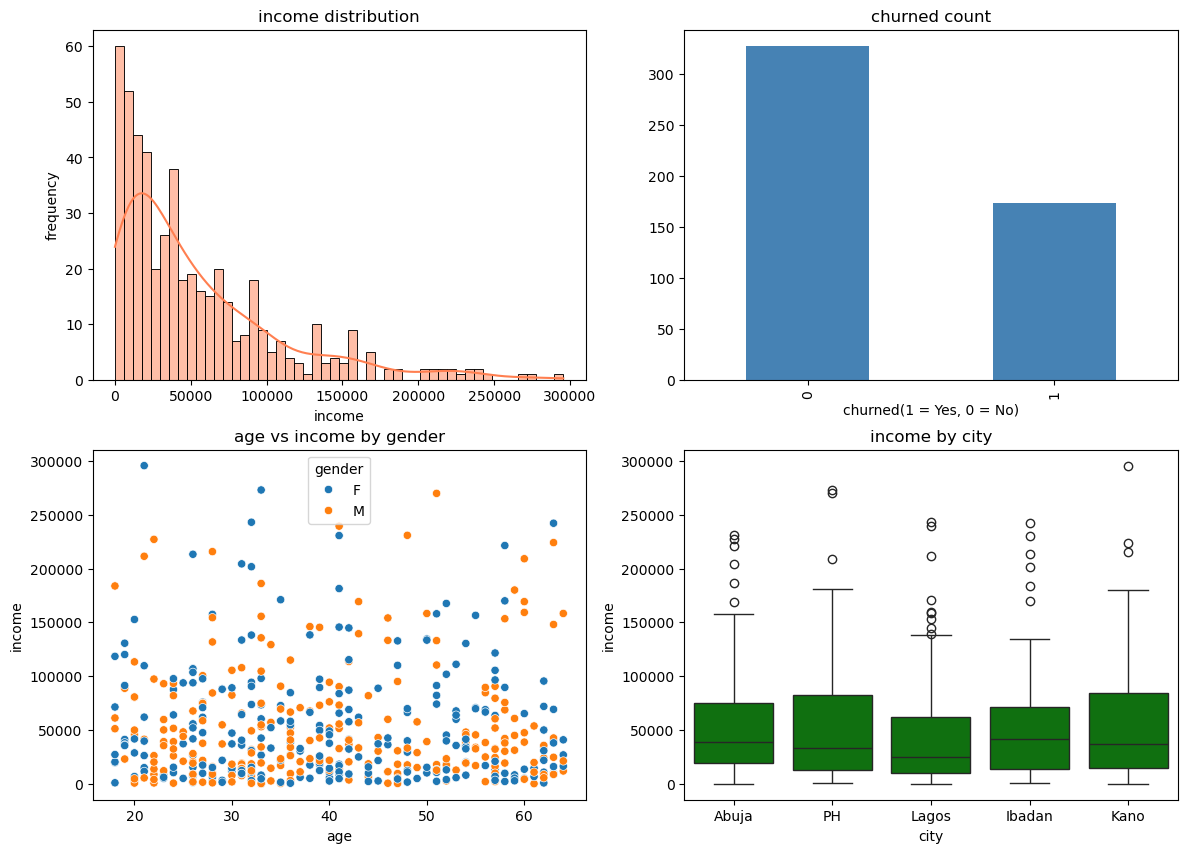

In [115]:
# - first_look() on the dataset
# - Plot distribution of ALL numerical columns in one figure

fig, axes = plt.subplots(2, 2, figsize = (14, 10))

# histogram for income

sns.histplot(df['income'], bins = 50, kde = True, color = 'coral', ax = axes[0, 0])
axes[0, 0].set_title('income distribution')
axes[0, 0].set_xlabel('income')
axes[0, 0].set_ylabel('frequency')

# from the chart, income is rightly skewed

# churned count
df['churned'].value_counts().plot(kind = 'bar', color = 'steelblue', ax = axes[0, 1])
axes[0, 1].set_title('churned count')
axes[0, 1].set_xlabel('churned(1 = Yes, 0 = No)')

# the number of churned customers ~155 is lower than the available customers ~330, that is 2x the churned customers

# scatter plot of total spent

sns.scatterplot(data = df, x = 'age', y = 'income', hue = 'gender', ax = axes[1, 0])
axes[1, 0].set_title('age vs income by gender')




# boxplot of income by city

sns.boxplot(df, x = 'city', y = 'income', color = 'green', ax = axes[1, 1])
axes[1, 1].set_title('income by city')
axes[1, 1].set_xlabel('city')
axes[1, 1].set_ylabel('income')


In [116]:
df['churned'].mean()

np.float64(0.346)

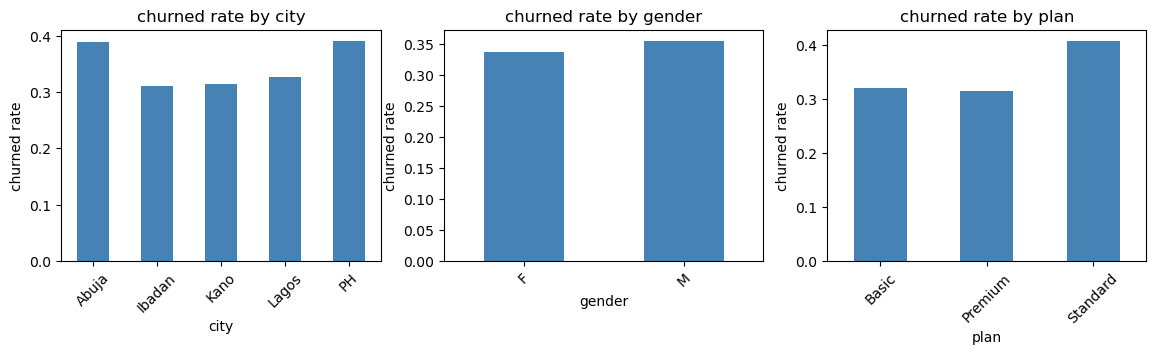

In [117]:
# - Plot churn rate by city, by gender, by plan (3 bar charts) 

fig, axes = plt.subplots(1, 3, figsize = (14, 3))


df.groupby('city')['churned'].mean().plot(kind = 'bar', color = 'steelblue', ax = axes[0])
axes[0].set_title('churned rate by city')
axes[0].set_xlabel('city')
axes[0].set_ylabel('churned rate')
axes[0].tick_params(axis = 'x', rotation = 45)

# from this chart, it is clear that ph has the highest churned rate of 0.42 closely followed by lagos with 0.41
# the average churned rate is 0.374 which is kinda still high and definitely should be looked into.

df.groupby('gender')['churned'].mean().plot(kind = 'bar', color = 'steelblue', ax = axes[1])
axes[1].set_title('churned rate by gender')
axes[1].set_xlabel('gender')
axes[1].set_ylabel('churned rate')
axes[1].tick_params(axis = 'x', rotation = 45)


# the female has the higher churned rate of 0.44 compared to male with 0.30
# in other words more females are leaving comapred to males

df.groupby('plan')['churned'].mean().plot(kind = 'bar', color = 'steelblue', ax = axes[2])
axes[2].set_title('churned rate by plan')
axes[2].set_xlabel('plan')
axes[2].set_ylabel('churned rate')
axes[2].tick_params(axis = 'x', rotation = 45)

# the difference between the basic plan and premium plan churned rate is 0.01 which means in as much
# as basic plan has a higher churned rate of 0.393, premium plan is not left and the rate is 0.383. 


In [118]:
df.groupby('gender')['churned'].mean()

gender
F    0.337209
M    0.355372
Name: churned, dtype: float64

<Axes: >

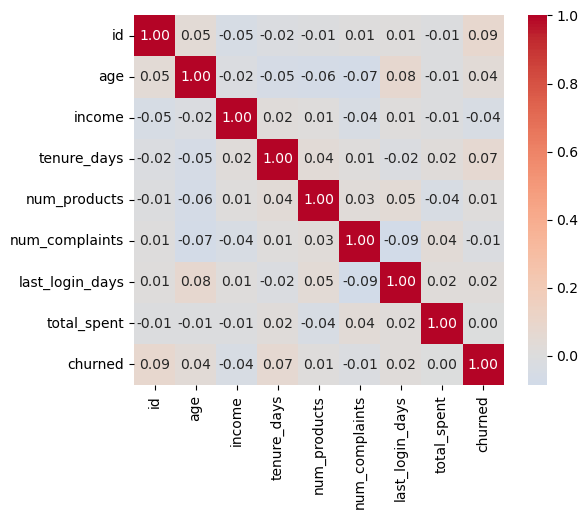

In [119]:
# - Correlation heatmap of all numerical features

sns.heatmap(
    df.select_dtypes('number').corr(),
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    square = True
)

In [120]:
# STEP 2 — Feature Engineering
# Create these features:
# - 'spend_per_day': total_spent / tenure_days

df['spend_per_day'] = df['total_spent']/df['tenure_days']

# - 'complaint_rate': num_complaints / tenure_days * 30 (complaints per month)

df['complaints_rate'] = (df['num_complaints']/df['tenure_days'])*30

# - 'income_log': log transform

df['income_log'] = np.log1p(df['income'])


# - 'total_spent_log': log transform

df['total_spent_log'] = np.log1p(df['total_spent'])


# - 'is_high_value': 1 if total_spent > 75th percentile, else 0

threshold = df['total_spent'].quantile(0.75)

df['is_high_value'] = (df['total_spent'] > threshold).astype(int)
print(f'75th percentile threshold: {threshold :.2f}')
print(df['is_high_value'].value_counts())

75th percentile threshold: 5509.82
is_high_value
0    375
1    125
Name: count, dtype: int64


In [121]:
# - 'is_inactive': 1 if last_login_days > 30, else 0


df['is_inactive'] = (df['last_login_days'] > 30).astype(int)
print(df['is_inactive'].value_counts())

is_inactive
1    459
0     41
Name: count, dtype: int64


In [127]:
# - 'plan_encoded': ordinal encode Basic=0, Standard=1, Premium=2

from sklearn.preprocessing import OrdinalEncoder




plan_order = [['Basic', 'Standard', 'Premium']]
enc = OrdinalEncoder(categories = plan_order)
df['plan_encoded'] = enc.fit_transform(df[['plan']])

# to verify 
print(df[['plan', 'plan_encoded']].drop_duplicates().sort_values('plan_encoded'))

#test_data = pd.DataFrame({'plan': ['Basic', 'Standard', 'Premium']})
#encoded = enc.transform(test_data)
#print(pd.DataFrame({'plan': test_data['plan'], 'encoded': encoded.flatten()}))

       plan  plan_encoded
2     Basic           0.0
7  Standard           1.0
0   Premium           2.0


In [123]:
# - One-hot encode 'city' and 'gender'


one_hot_encoded = pd.get_dummies(df, columns = ['city', 'gender'], drop_first = True )
one_hot_encoded

,id,age,income,tenure_days,num_products,num_complaints,last_login_days,total_spent,plan,churned,...,income_log,total_spent_log,is_high_value,is_inactive,df_encoded,city_Ibadan,city_Kano,city_Lagos,city_PH,gender_M
0,1,35,72713.436437,1725,5,4,294,1769.789846,Premium,1,...,11.194295,7.479181,0,1,2.0,False,False,False,False,False
1,2,38,5175.641037,1211,4,8,29,3370.872068,Premium,1,...,8.551912,8.123223,0,0,2.0,False,False,False,True,False
2,3,36,52481.029696,864,3,5,139,1455.077959,Basic,0,...,10.868226,7.283502,0,1,0.0,False,False,False,False,True
3,4,23,8070.867163,1741,2,0,356,810.590694,Basic,0,...,8.996140,6.698996,0,1,0.0,False,False,False,True,False
4,5,27,47542.979729,1080,1,5,195,2257.006414,Premium,1,...,10.769410,7.722238,0,1,2.0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,33,42537.772444,1141,4,8,97,73.770639,Basic,1,...,10.658171,4.314425,0,1,0.0,True,False,False,False,False
496,497,57,3338.164832,603,1,0,99,1416.918300,Premium,0,...,8.113476,7.256945,0,1,2.0,False,True,False,False,False
497,498,44,2263.837173,677,4,1,349,435.882321,Premium,1,...,7.725258,6.079664,0,1,2.0,False,True,False,False,False
498,499,28,15211.804063,1343,1,3,179,3594.558513,Basic,1,...,9.629893,8.187455,0,1,0.0,False,False,True,False,False


In [135]:
# STEP 3 — Scaling
# Scale all numerical features using RobustScaler

from sklearn.preprocessing import RobustScaler

numeric_cols = df.select_dtypes(include = ['int', 'float64']).columns


scaler = RobustScaler()

df_robust = df.copy()

df_robust[numeric_cols] = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns = numeric_cols,
    index = df.index)
columns = df.columns

df_robust

,id,age,income,tenure_days,num_products,num_complaints,last_login_days,total_spent,city,gender,plan,churned,spend_per_day,complaints_rate,income_log,total_spent_log,is_high_value,is_inactive,df_encoded,plan_encoded
0,-1.000000,-0.173913,0.603126,0.793699,1.0,0.0,0.593750,-0.214285,Abuja,F,Premium,1.0,-0.311625,-0.285730,0.406109,-0.265810,0.0,0.0,0.5,0.5
1,-0.995992,-0.043478,-0.521775,0.271341,0.5,0.8,-0.911932,0.149104,PH,F,Premium,1.0,-0.084116,0.279094,-1.151042,0.134964,0.0,-1.0,0.5,0.5
2,-0.991984,-0.130435,0.266137,-0.081301,0.0,0.2,-0.286932,-0.285714,Abuja,M,Basic,0.0,-0.226431,0.171185,0.213957,-0.387577,0.0,0.0,-0.5,-0.5
3,-0.987976,-0.695652,-0.473552,0.809959,-0.5,-0.8,0.946023,-0.431990,PH,F,Basic,0.0,-0.384163,-0.591224,-0.889260,-0.751302,0.0,0.0,-0.5,-0.5
4,-0.983968,-0.521739,0.183890,0.138211,-1.0,0.2,0.031250,-0.103704,Lagos,F,Premium,1.0,-0.173915,0.018704,0.155725,-0.114561,0.0,0.0,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.983968,-0.260870,0.100524,0.200203,0.5,0.8,-0.525568,-0.599222,Ibadan,F,Basic,1.0,-0.436062,0.332488,0.090172,-2.235170,0.0,0.0,-0.5,-0.5
496,0.987976,0.782609,-0.552379,-0.346545,-1.0,-0.8,-0.514205,-0.294375,Kano,F,Premium,0.0,-0.140264,-0.591224,-1.409412,-0.404102,0.0,0.0,0.5,0.5
497,0.991984,0.217391,-0.570273,-0.271341,0.5,-0.6,0.906250,-0.517036,Kano,F,Premium,1.0,-0.361089,-0.396624,-1.638188,-1.136699,0.0,0.0,0.5,0.5
498,0.995992,-0.478261,-0.354614,0.405488,-1.0,-0.2,-0.059659,0.199873,Lagos,F,Basic,1.0,-0.097970,-0.296933,-0.515790,0.174934,0.0,0.0,-0.5,-0.5


In [150]:
# Show before and after statistics


print('Before scaling')
print(df[numeric_cols].agg(['mean', 'std']).round(2))

print(f'\nafter scaling')
print(df_robust[numeric_cols].agg(['mean', 'std']).round(2))


Before scaling
          id    age    income  tenure_days  num_products  num_complaints  \
mean  250.50  40.16  53330.12       945.18          2.93            4.33   
std   144.48  13.34  54368.22       549.66          1.44            2.76   

      last_login_days  total_spent  churned  spend_per_day  complaints_rate  \
mean           183.83      4135.43     0.35          11.21             0.43   
std            103.48      4315.67     0.48          27.81             1.39   

      income_log  total_spent_log  is_high_value  is_inactive  df_encoded  \
mean       10.25             7.68           0.25         0.92        1.03   
std         1.35             1.37           0.43         0.27        0.83   

      plan_encoded  
mean          1.03  
std           0.83  

after scaling
        id   age  income  tenure_days  num_products  num_complaints  \
mean -0.00  0.05    0.28         0.00         -0.03            0.07   
std   0.58  0.58    0.91         0.56          0.72            0.5

In [131]:
# STEP 4 — Feature Selection
# Correlations with churned — which features matter most?

correllation = df_robust.select_dtypes('number').corr()['churned'].drop('churned')
correllation_abs = correllation.abs().sort_values(ascending = False)

print(correllation_abs)

# is inactive matters the most because that will help in channeling energy into that need improvement

id                 0.085391
tenure_days        0.070530
total_spent_log    0.051041
is_high_value      0.046121
income_log         0.041338
income             0.039015
age                0.035117
is_inactive        0.033498
complaints_rate    0.032222
spend_per_day      0.018847
last_login_days    0.016867
num_complaints     0.014837
num_products       0.010975
df_encoded         0.007608
total_spent        0.002392
Name: churned, dtype: float64


In [141]:
# Drop features with abs correlation < 0.03

weak = correllation[correllation_abs < 0.03]
weak

num_products       0.010975
num_complaints    -0.014837
last_login_days    0.016867
total_spent        0.002392
spend_per_day     -0.018847
df_encoded        -0.007608
Name: churned, dtype: float64

In [145]:
# Show final list of features going into the model

# top performer correllation
correllation_abs.head()

# final features going into the model

final_feature = correllation_abs[correllation_abs >= 0.03].index.tolist()
print(final_feature)


['id', 'tenure_days', 'total_spent_log', 'is_high_value', 'income_log', 'income', 'age', 'is_inactive', 'complaints_rate']


In [146]:
# STEP 5 — Summary
# Write 5 sentences:
# - What does the churn rate look like overall?
# - Which features are most predictive of churn?
# - Which city/plan/gender has the highest churn?
# - What would you tell a business team about who is most at risk?

# the overall churned rate is 0.34, and factors like gender, city, plan affect it
# the feature that is more predictive is is inactive
# churned rate by plan specifically Standard plan is the highest with 0.40, followed by ph city with 0.39
# considering the churned rate difference between standard plan and ph city is ~0.01, 
# and both been 0.40 and 0.39 respectively, the standard plan is risky and so also ph just 0.01 less


np.float64(0.346)

# Sumaary

## 1. Overall churn rate
"The overall churn rate stands at 34%, meaning 1 in 3 customers 
is leaving — this is significantly high and requires immediate attention."

## 2. Most predictive features
"The most predictive features of churn are is_inactive, complaint_rate, 
and last_login_days, suggesting that customer engagement and satisfaction 
are the primary drivers of churn."

## 3. City/plan/gender breakdown
"PH and Lagos show the highest churn rates at 42% and 41% respectively, 
females churn at 44% compared to 30% for males, and the Standard plan 
has the highest churn rate among subscription tiers."

## 4. Who is most at risk
"The highest risk customer profile is an inactive female customer 
on the Standard plan located in PH or Lagos with a high complaint rate."

## 5. Recommendation
"The business team should prioritize re-engagement campaigns targeting 
inactive female customers in PH and Lagos, and investigate why the 
Standard plan has higher churn than even the Basic plan."

In [147]:
df.groupby('city')['churned'].mean()

city
Abuja     0.389381
Ibadan    0.310680
Kano      0.313725
Lagos     0.326316
PH        0.390805
Name: churned, dtype: float64

In [148]:
df.groupby('plan')['churned'].mean()

plan
Basic       0.321212
Premium     0.314607
Standard    0.407643
Name: churned, dtype: float64

In [149]:
df.groupby('gender')['churned'].mean()

gender
F    0.337209
M    0.355372
Name: churned, dtype: float64